In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


EXPERIMENTS = [
    "sn_kjOrdinalDM_xnjNormal",
    "sn_kjOrdinalDM_xnjNonNormal",
    "sn_kjOrdinalUniform_xnjNormal",
    "sn_kjOrdinalUniform_xnjNonNormal",
    "sn_kjContinuousUniform",
    "sn_kjContinuousBeta",
    "xiNearNormal_kjContinuousUniform",
    "xiNearNormal_kjContinuousBeta",
    "xiNearNormalWithNoise_kjContinuousBeta",
]

titles = [
        "Exp 1: S + Ordinal kj (DM) + X (Normal)",
        "Exp 2: S + Ordinal kj (DM) + X (Non-Normal)",
        "Exp 3: S + Ordinal kj (Uniform) + X (Normal)",
        "Exp 4: S + Ordinal kj (Uniform) + X (Non-Normal)",
        "Exp 5: S + Continuous kj (Uniform)",
        "Exp 6: S + Continuous kj (Skewed)",
        "Exp 7: xi (Normal) + Continuous kj (Uniform)",
        "Exp 8: xi (Normal) + Continuous kj (Skewed)",
        "Exp 9: xi (Normal + Noise) + Continuous kj (Skewed)"
    ]
code2title = dict(zip(EXPERIMENTS, titles))
title2code = {v: k for k, v in code2title.items()}  # optional, reverse map

In [6]:
df_old = pd.read_csv("../all_results_100bio.csv")
df_tr  = pd.read_csv("../all_results_100bio_transformer.csv")
df_tr["kendalls_tau"] = (1 - df_tr["kendalls_tau"]) / 2

# transformer csv uses short codes -> map to titles used in df_old
df_tr["E"] = df_tr["E"].map(code2title).fillna(df_tr["E"])

# ensure runtime exists (optional)
if "runtime" not in df_tr.columns:
    df_tr["runtime"] = np.nan

df_all = pd.concat([df_old, df_tr], ignore_index=True)

# make sure nothing weird is missing
df = df_all.dropna(subset=["E", "algo"])

df.to_csv('100bio.csv', index=False)

In [7]:
# df = pd.read_csv('../all_results.csv')
def mean_ci(x):
    mean = x.mean()
    sem = x.std(ddof=1) / np.sqrt(len(x))
    ci = 1.96 * sem
    return mean, ci

In [8]:
def plot_metric_by_E(df, metric, ylabel, value_fmt="{:.3f}"):
    Es = sorted(df["E"].unique())
    algos = sorted(df["algo"].unique())

    # consistent color mapping
    colors = plt.cm.tab10.colors[:len(algos)]
    algo2color = dict(zip(algos, colors))

    ncols = 3
    nrows = int(np.ceil(len(Es) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.8 * ncols, 3.8 * nrows),
        sharey=True
    )
    axes = axes.flatten()

    for i, E in enumerate(Es):
        ax = axes[i]
        df_E = df[df["E"] == E]

        means, cis = [], []

        for algo in algos:
            vals = df_E[df_E["algo"] == algo][metric]
            m, ci = mean_ci(vals)
            if metric == 'kendalls_tau':
                means.append(1-2*m)
            else:
                means.append(m)
            cis.append(ci)

        x = np.arange(len(algos))

        bars = ax.bar(
            x,
            means,
            yerr=cis,
            capsize=4,
            color=[algo2color[a] for a in algos],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )

        # ---- annotate mean values ----
        for bar, m in zip(bars, means):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.05,
                value_fmt.format(m),
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=0
            )

        ax.set_title(f"{E}")
        ax.set_xticks(x)
        ax.set_xticklabels(algos, rotation=30, ha="right")

        if i % ncols == 0:
            ax.set_ylabel(ylabel)

        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # shared legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=algo2color[a], ec="black", lw=0.6)
        for a in algos
    ]
    fig.legend(
        handles,
        algos,
        loc="lower center",
        ncol=len(algos),
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)
    )

    fig.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


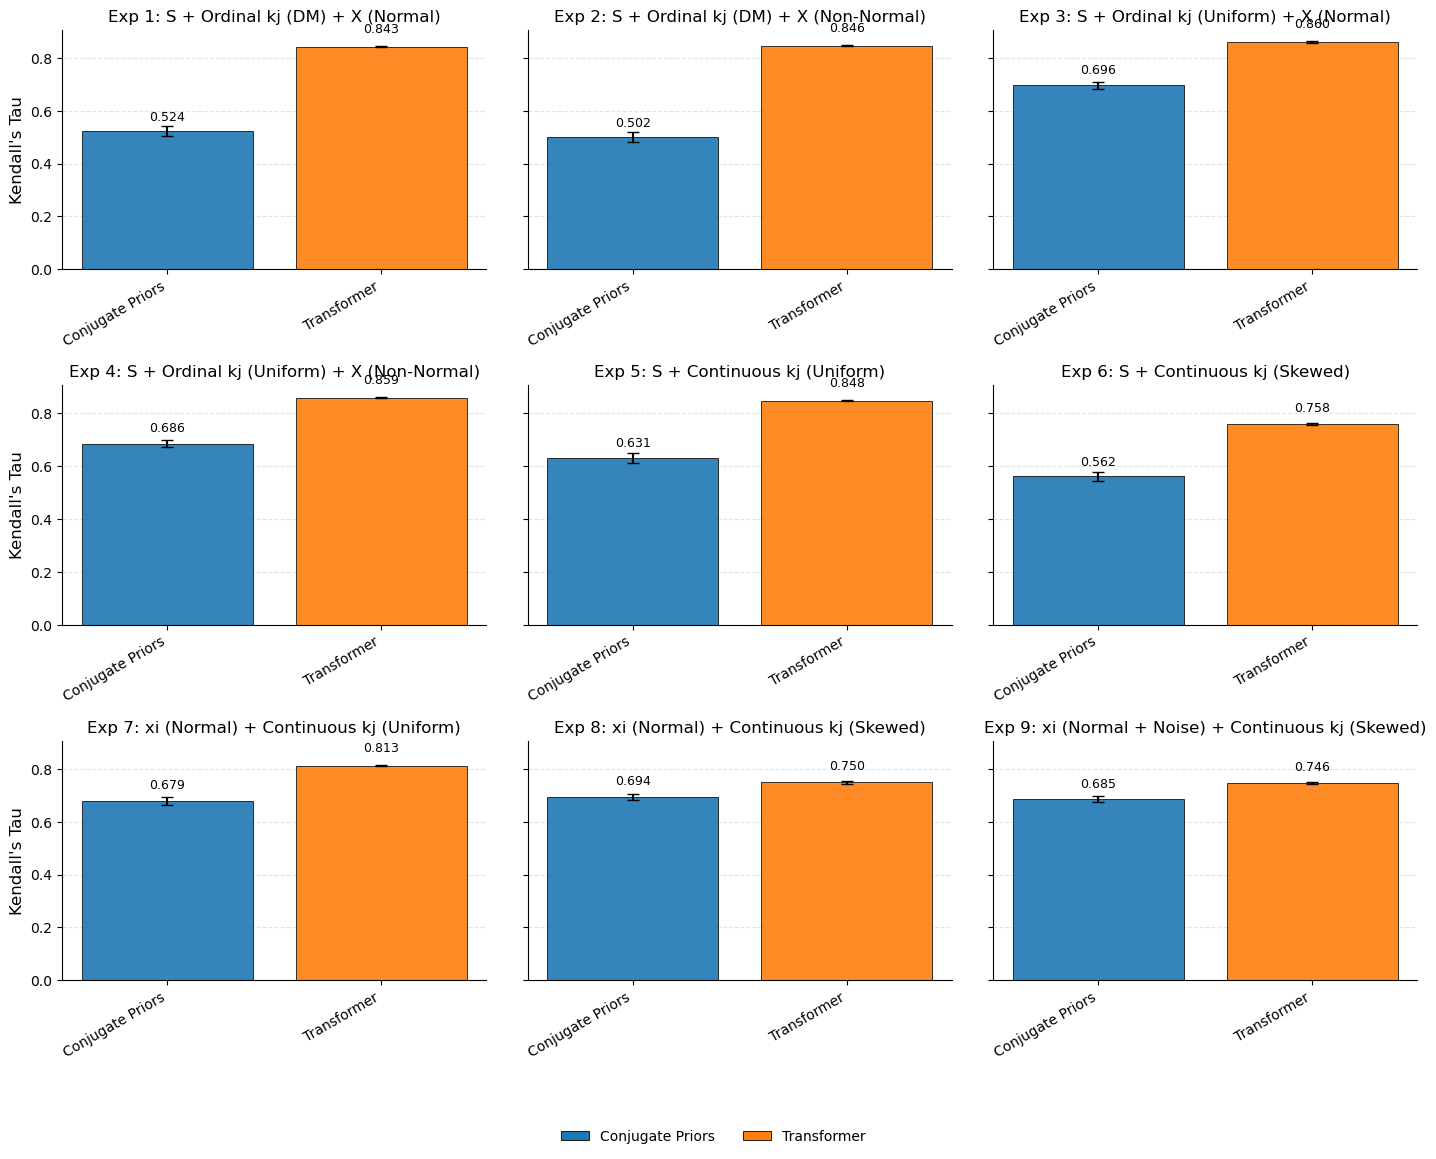

In [9]:
fig_tau = plot_metric_by_E(
    df,
    metric="kendalls_tau",
    ylabel="Kendall's Tau",
    value_fmt="{:.3f}"
)


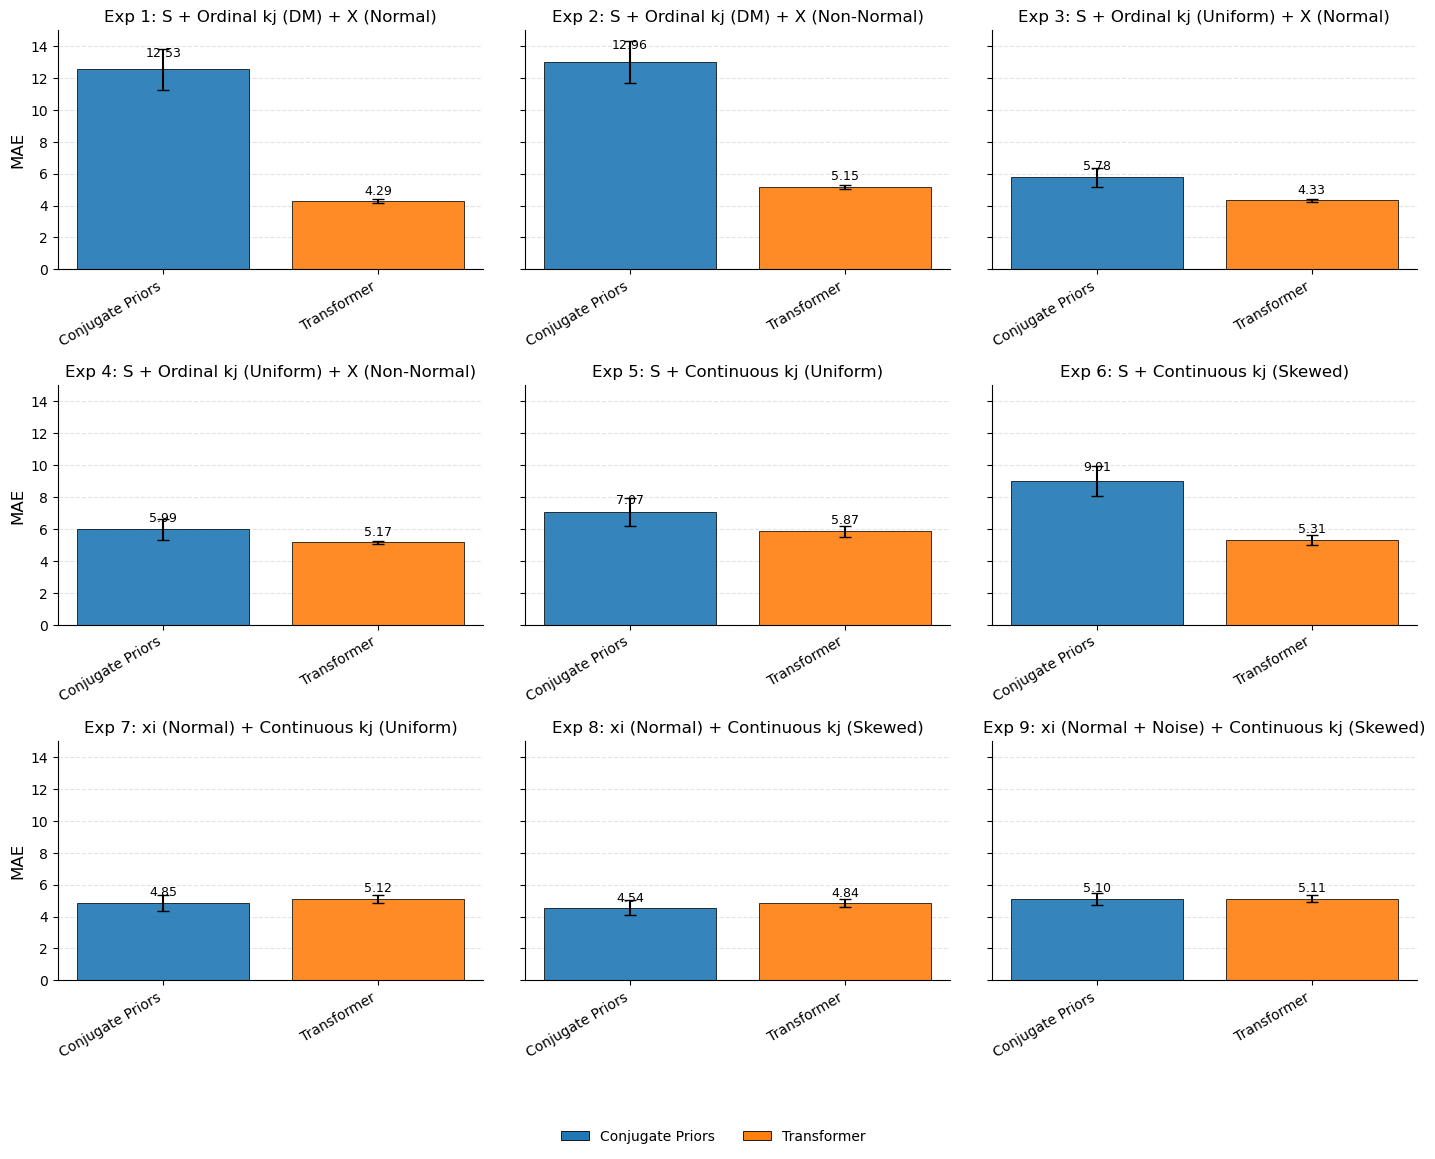

In [10]:
fig_mae = plot_metric_by_E(
    df,
    metric="mae",
    ylabel="MAE",
    value_fmt="{:.2f}"
)
